# SAMI · Notebook 1 — The input & the audience  ·  *Act 1*

**Question:** what data do we have, can we trust it, and who is SAMI reaching?

SAMI is a WhatsApp chatbot for migrants in Colombia. This notebook establishes the
evidentiary base for everything that follows: it profiles the two data sources, states
their limits plainly, and draws the audience portrait — one variable at a time, no
cross-cuts (those belong to NB2).

*Reproducibility:* every number traces to the reconciliation table (printed at the top
**and** bottom of this notebook — the two must match). All cleaning lives in `src/sami/`;
this notebook only consumes it. No raw phone number renders anywhere (PII gate).

In [1]:
import sys, pathlib
# Locate src/ by walking up from the working directory, so `sami` imports
# whether the kernel starts in notebooks/ (JupyterLab) or at the repo root
# (VS Code) — a bare "../src" only works in the first case.
_cwd = pathlib.Path.cwd()
_src = next((p / "src" for p in (_cwd, *_cwd.parents) if (p / "src" / "sami").is_dir()), None)
if _src is None:
    raise RuntimeError(f"Could not find src/sami/ above {_cwd}. "
                       "Run this notebook from inside the repository.")
sys.path.insert(0, str(_src))
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from sami import load_sami, theme, canon, geo, qa, cohort

WINDOW = None  # filled after load; every subtitle carries metric + n + window

def titled(ax, title, subtitle, source="Source: SAMI bot responses log."):
    # Assertion-evidence title (the finding), then subtitle (metric + n + window),
    # then source. Title sits well above the axes (pad) so the subtitle, placed
    # just above the axes top, never collides with it.
    ax.set_title(title, loc="left", fontsize=12.5, fontweight="semibold", color=theme.INK, pad=30)
    ax.annotate(subtitle, xy=(0, 1.0), xycoords="axes fraction", xytext=(0, 8),
                textcoords="offset points", fontsize=9.5, color=theme.INK2, va="bottom")
    ax.annotate(source, xy=(0, 0), xycoords="axes fraction", xytext=(0, -42),
                textcoords="offset points", fontsize=8, color=theme.MUTED, va="top")


def titled_map(fig, ax, title, subtitle, source):
    # Full-bleed maps (axis off) have no data margin, so stack the title block at
    # FIGURE coordinates above the map and reserve headroom via subplots_adjust.
    fig.subplots_adjust(top=0.86, bottom=0.08, left=0.02, right=0.98)
    fig.text(0.02, 0.965, title, fontsize=12.5, fontweight="semibold", color=theme.INK, ha="left", va="top")
    fig.text(0.02, 0.915, subtitle, fontsize=9.5, color=theme.INK2, ha="left", va="top")
    fig.text(0.02, 0.015, source, fontsize=8, color=theme.MUTED, ha="left", va="bottom")

d = load_sami()
r = d.responses
m = d.meal
msgs = d.messages
WINDOW = f"{pd.to_datetime(d.run_meta['ts_min']).date()} – {pd.to_datetime(d.run_meta['ts_max']).date()}"

# user-level profile frame (one row per user; 26 users have 2-3 records)
users = r.sort_values("ts").drop_duplicates("user_id", keep="first").reset_index(drop=True)
N_USERS = users["user_id"].nunique()

# v1/v2 registration-survey cohort, per cohort.py — some fields (nationality)
# cannot be pooled across the rewrite, others (away_duration) exist only for
# v1. Tag both frames once here so every downstream cell can filter/split
# without re-deriving it.
r = r.assign(instrument_version=cohort.instrument_version(r).values)
users = users.assign(instrument_version=cohort.instrument_version(users).values)

print("Analysis window:", WINDOW, "| users:", N_USERS, "| records:", len(r), "| messages:", len(msgs))
print("Cohorts (users):", users["instrument_version"].value_counts().to_dict())


Analysis window: 2026-03-25 – 2026-07-28 | users: 1392 | records: 1459 | messages: 4663
Cohorts (users): {'v1': 1314, 'v2': 78}


## Reconciliation table (P10) — the run's identity card
Every figure's *n* traces here. The identical table is reprinted at the close.

In [2]:
recon = d.reconciliation
print(f"Export: {d.run_meta['responses_file']}  +  {d.run_meta['meal_file']}")
print(f"Window: {WINDOW}   Rows(responses/meal): {d.run_meta['responses_rows']}/{d.run_meta['meal_rows']}\n")
display(recon)
# PII gate: zero whatsapp:/phone runs in any frame we will render from
assert all(len(qa.pii_scan(f)) == 0 for f in (r, msgs, m)), "PII gate failed"
print("PII gate: clean (no whatsapp:/7+-digit runs in responses, messages, meal).")

Export: Users_Group_Title_2807.xlsx  +  Survey_Responses_Group_Title_2807.xlsx
Window: 2026-03-25 – 2026-07-28   Rows(responses/meal): 1460/142



,metric,value
0,users,1392
1,records,1459
2,messages,4663
3,users_with_text,1198
4,meal_responses,115
5,meal_response_rate_pct,8.3
6,repeat_askers_pct,10.6
7,negative_tone_pct,pending


PII gate: clean (no whatsapp:/7+-digit runs in responses, messages, meal).


## 1 · Sources & reliability

Two sources feed the analysis: the **bot responses log** (every user who completed the
intake form) and the **MEAL survey** (a voluntary satisfaction follow-up). Their
completeness and reach set the ceiling on what we can claim.

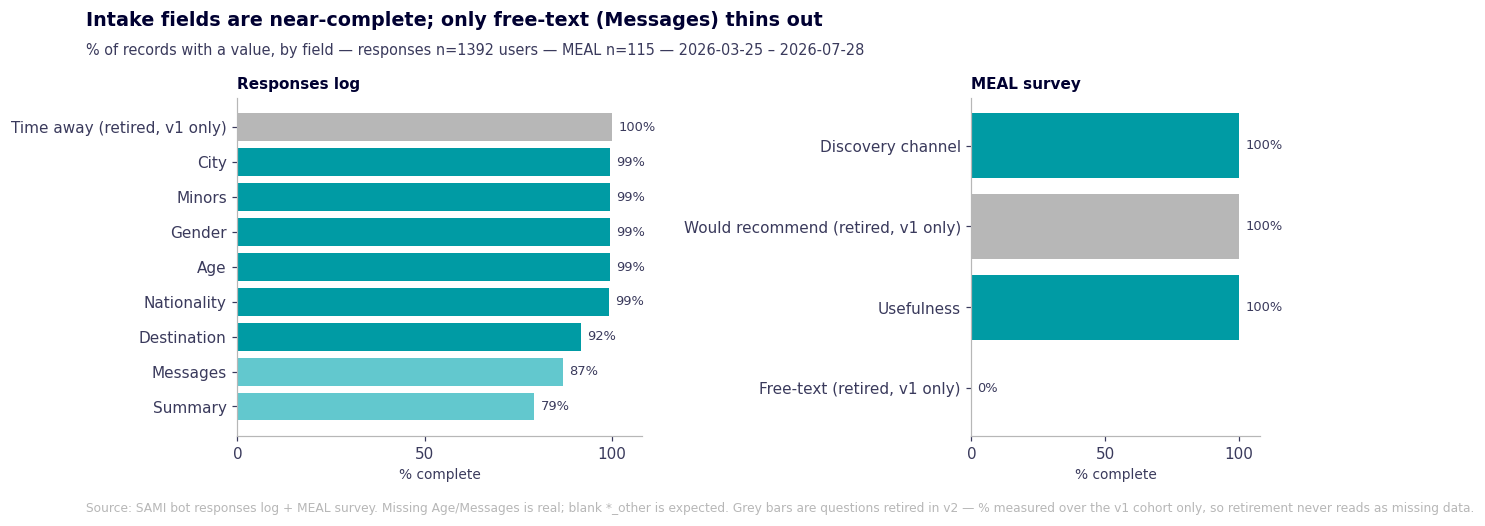

In [3]:
# Figure 1 — field completeness per source (two panels)
# Away_duration (responses) and would_recommend/recommendation_text (MEAL) are
# retired in v2 (cohort.POLICY marks them V1_ONLY) — v2 respondents were never
# asked, so pooling their absence into the overall rate would misreport a
# deliberate removal as data loss. Each is instead measured over the v1
# cohort it actually covers and flagged grey + "(retired, v1 only)", the same
# idiom Figure 4 uses to flag the self-reported sub-18 band.
resp_fields = {
    "Nationality": "nationality_clean", "City": "city_clean", "Gender": "gender_clean",
    "Age": "age_num", "Minors": "Minors", "Time away": "Away_duration",
    "Destination": "Destination_Country", "Messages": "Messages", "Summary": "Chat_summary",
}
def pct_complete(df, col):
    s = df[col].astype("string").str.strip()
    return 100 * s.replace({"": pd.NA, "nan": pd.NA, "None": pd.NA}).notna().mean()

RETIRED_RESP = {"Time away"}
resp_v1 = users[users["instrument_version"] == "v1"]
resp_c = pd.Series({
    k: pct_complete(resp_v1 if k in RETIRED_RESP else users, v)
    for k, v in resp_fields.items()
}).sort_values()

meal_fields = {"Usefulness": "usefulness_rating", "Would recommend": "would_recommend",
               "Free-text": "recommendation_text", "Discovery channel": "discovery_channel"}
RETIRED_MEAL = {"Would recommend", "Free-text"}
# MEAL carries no v1/v2 marker of its own; borrow it from the responses log.
meal_iv = m.merge(r[["user_id", "instrument_version"]].drop_duplicates("user_id"), on="user_id", how="left")
meal_v1 = meal_iv[meal_iv["instrument_version"] == "v1"]
meal_c = pd.Series({
    k: pct_complete(meal_v1 if k in RETIRED_MEAL else m, v)
    for k, v in meal_fields.items()
}).sort_values()

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.8), gridspec_kw={"width_ratios": [1.4, 1]})
for ax, s, lab, retired in [(a1, resp_c, "Responses log", RETIRED_RESP), (a2, meal_c, "MEAL survey", RETIRED_MEAL)]:
    cols = [theme.MUTED if k in retired else (theme.PRIMARY if v >= 90 else (theme.AGUA_MID if v >= 60 else theme.MADERA))
            for k, v in s.items()]
    labels = [f"{k} (retired, v1 only)" if k in retired else k for k in s.index]
    ax.barh(labels, s.values, color=cols)
    for y, v in enumerate(s.values):
        ax.annotate(f"{v:.0f}%", (v, y), xytext=(4, 0), textcoords="offset points",
                    va="center", fontsize=8.5, color=theme.INK2)
    ax.set_xlim(0, 108); ax.set_xticks([0, 50, 100]); ax.set_xlabel("% complete", fontsize=9)
    ax.set_title(lab, loc="left", fontsize=10, fontweight="semibold", color=theme.INK, pad=6)
fig.subplots_adjust(top=0.80, bottom=0.16, wspace=0.95)
fig.text(0.01, 0.965, "Intake fields are near-complete; only free-text (Messages) thins out",
         fontsize=12.5, fontweight="semibold", color=theme.INK, ha="left", va="top")
fig.text(0.01, 0.905, f"% of records with a value, by field — responses n={N_USERS} users — MEAL n={len(m)} — {WINDOW}",
         fontsize=9.5, color=theme.INK2, ha="left", va="top")
fig.text(0.01, 0.01,
         "Source: SAMI bot responses log + MEAL survey. Missing Age/Messages is real; blank *_other is expected. "
         "Grey bars are questions retired in v2 — % measured over the v1 cohort only, so retirement never reads as missing data.",
         fontsize=8, color=theme.MUTED, ha="left", va="bottom")
plt.show()


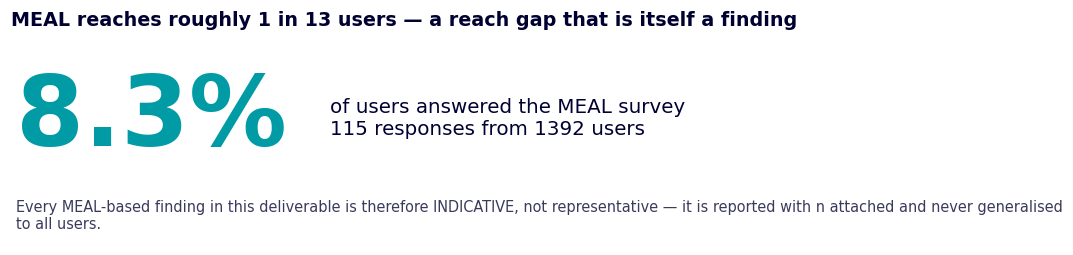

In [4]:
# Figure 2 — MEAL response-rate big-number callout (not a chart)
rate = 100 * len(m) / N_USERS
fig, ax = plt.subplots(figsize=(11, 2.4)); ax.axis("off")
ax.text(0.005, 0.62, f"{rate:.1f}%", fontsize=64, fontweight="bold", color=theme.PRIMARY,
        va="center", ha="left", transform=ax.transAxes)
ax.text(0.34, 0.62, f"of users answered the MEAL survey\n{len(m)} responses from {N_USERS} users",
        fontsize=13, color=theme.INK, va="center", ha="left", transform=ax.transAxes)
ax.text(0.005, 0.06,
        "Every MEAL-based finding in this deliverable is therefore INDICATIVE, not representative "
        "— it is reported with n attached and never generalised to all users.",
        fontsize=9.5, color=theme.INK2, va="bottom", ha="left", transform=ax.transAxes, wrap=True)
ax.set_title("MEAL reaches roughly 1 in 13 users — a reach gap that is itself a finding",
             loc="left", fontsize=12.5, fontweight="semibold", color=theme.INK, pad=10)
plt.show()

## 2 · Audience profile

Who is SAMI actually reaching? Five single-variable cuts — gender, nationality, age,
care responsibilities and geography. The headline emerges by the end of the section:
this is a **settled**, working-age, overwhelmingly Venezuelan population concentrated
in a handful of cities — an audience for *integration* support, not route information.


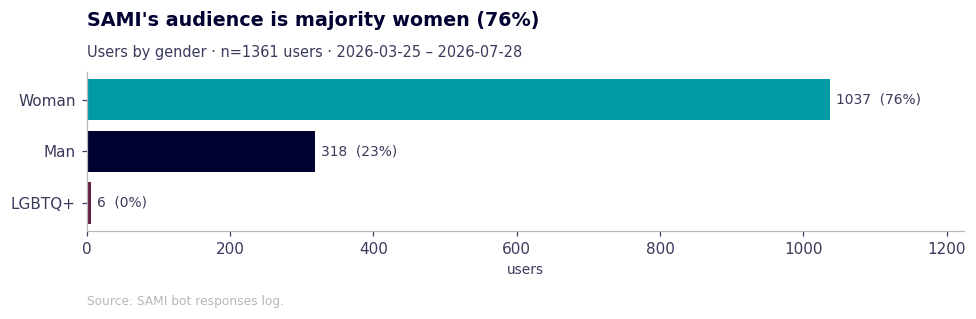

In [5]:
# Figure 3 — gender (plain horizontal bar; the non-answer bucket set apart in grey)
g = users["gender_clean"].map(canon.gender_display).value_counts()
g = g.reindex(["Woman", "Man", "LGBTQ+", "Prefer not to say", "Other"]).dropna()
share = 100 * g / g.sum()
# Woman/Man carry brand identity colours; the two non-answers stay neutral so a
# declined answer never reads as just another group. Five labels, not six:
# trans/non-binary self-descriptions fold into LGBTQ+ because a named 4-person
# cell is re-identifying (canon.py, 2026-07-29). "Other" and "Prefer not to say"
# stay apart -- a stated identity and a refusal are different answers.
GENDER_C = {"Woman": theme.PRIMARY, "Man": theme.DEEP, "LGBTQ+": theme.ACCENT,
            "Prefer not to say": theme.MUTED, "Other": theme.HONGO}
colors = [GENDER_C.get(k, theme.MUTED) for k in g.index]
fig, ax = plt.subplots(figsize=(9, 3.0))
ax.barh(g.index[::-1], g.values[::-1], color=colors[::-1])
for y, (n, p) in enumerate(zip(g.values[::-1], share.values[::-1])):
    ax.annotate(f"{int(n)}  ({p:.0f}%)", (n, y), xytext=(4, 0), textcoords="offset points",
                va="center", fontsize=9, color=theme.INK2)
ax.set_xlim(0, g.max() * 1.18); ax.set_xlabel("users", fontsize=9)
titled(ax, f"SAMI's audience is majority women ({share.iloc[0]:.0f}%)",
       f"Users by gender · n={int(g.sum())} users · {WINDOW}")
plt.tight_layout(); plt.show()


**Read these panels separately.** The v1 registration survey ended the
conversation for anyone who selected "Colombia" (question Q3), so Colombian
respondents are effectively absent from the v1 panel by design — 4 of 1,314,
and all four reached us by leaving the dropdown blank and typing their
nationality into the free-text field, bypassing the screen-out. v2 removed
that exit: 14 of 78. Pooling these panels would report the old survey's exit
rule as a finding about who the service reaches.


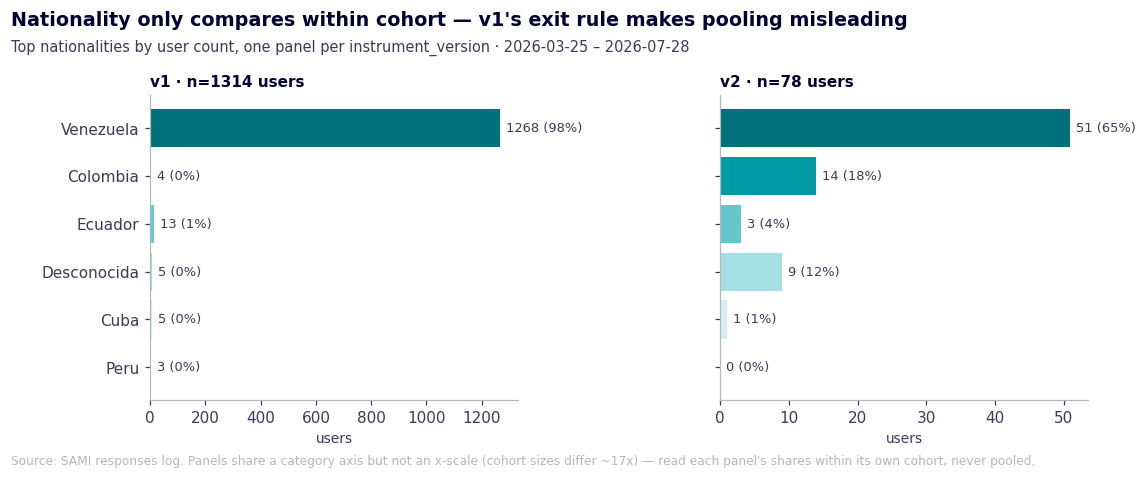

In [6]:
# Figure 4 — nationality, split by instrument_version (cohort.POLICY: SPLIT)
nat = users.groupby(["instrument_version", "nationality_canon"])["user_id"] \
           .nunique().reset_index(name="n_users")

overall_top = users["nationality_canon"].value_counts()
cats = overall_top.head(6).index.tolist()
if "Colombia" not in cats:
    cats.append("Colombia")  # the point of the split — keep it visible even if small
order = sorted(cats, key=lambda c: -overall_top.get(c, 0))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)
for ax, ver in [(a1, "v1"), (a2, "v2")]:
    n_cohort = int((users["instrument_version"] == ver).sum())
    sub = (nat[nat["instrument_version"] == ver]
           .set_index("nationality_canon")["n_users"].reindex(order).fillna(0))
    share = 100 * sub / sub.sum()
    ax.barh(order[::-1], sub.values[::-1], color=theme.seq_colors(len(order)))
    for y, (n, p) in enumerate(zip(sub.values[::-1], share.values[::-1])):
        ax.annotate(f"{int(n)} ({p:.0f}%)", (n, y), xytext=(4, 0), textcoords="offset points",
                    va="center", fontsize=8.5, color=theme.INK2)
    ax.set_xlabel("users", fontsize=9)
    ax.set_title(f"{ver} · n={n_cohort} users", loc="left", fontsize=10,
                 fontweight="semibold", color=theme.INK, pad=6)
fig.subplots_adjust(top=0.78, bottom=0.15, wspace=0.55)
fig.text(0.01, 0.955, "Nationality only compares within cohort — v1's exit rule makes pooling misleading",
         fontsize=12.5, fontweight="semibold", color=theme.INK, ha="left", va="top")
fig.text(0.01, 0.895, f"Top nationalities by user count, one panel per instrument_version · {WINDOW}",
         fontsize=9.5, color=theme.INK2, ha="left", va="top")
fig.text(0.01, 0.01,
         "Source: SAMI responses log. Panels share a category axis but not an x-scale (cohort sizes differ "
         "~17x) — read each panel's shares within its own cohort, never pooled.",
         fontsize=8, color=theme.MUTED, ha="left", va="bottom")
plt.show()


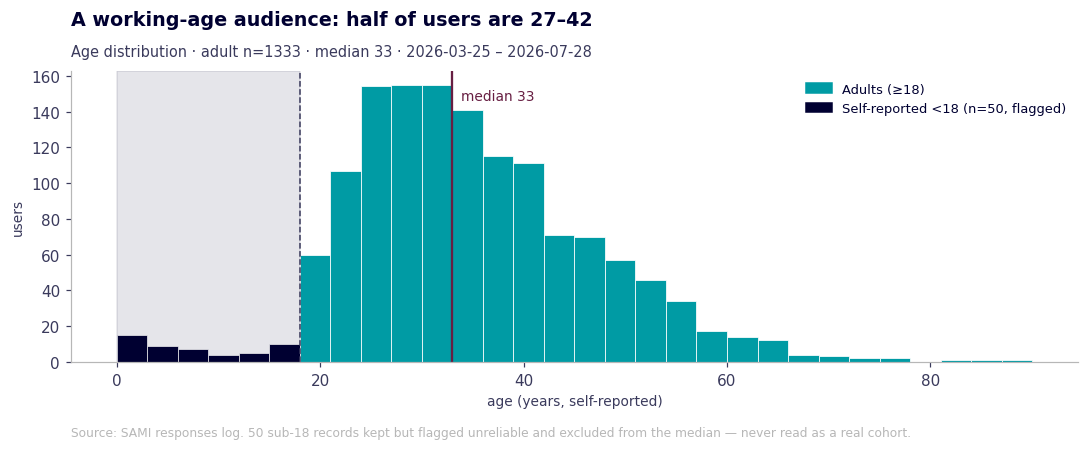

In [7]:
# Figure 5 — age distribution with sub-18 flagged band + honesty note
age = users["age_num"].dropna()
adult = age[age >= 18]
fig, ax = plt.subplots(figsize=(10, 4.2))
bins = np.arange(0, max(70, age.max()) + 5, 3)
ax.hist(adult, bins=bins, color=theme.PRIMARY, edgecolor="white", linewidth=0.5)
ax.hist(age[age < 18], bins=bins, color=theme.MADERA, edgecolor="white", linewidth=0.5)
ax.axvline(18, color=theme.INK2, lw=1, ls="--")
ax.axvspan(0, 18, color=theme.MADERA, alpha=0.10)
med = adult.median()
ax.axvline(med, color=theme.AMEBA, lw=1.5)
ax.annotate(f"median {med:.0f}", (med, ax.get_ylim()[1] * 0.9), xytext=(6, 0),
            textcoords="offset points", color=theme.AMEBA, fontsize=9)
ax.legend(handles=[Patch(color=theme.PRIMARY, label="Adults (≥18)"),
                   Patch(color=theme.MADERA, label=f"Self-reported <18 (n={int((age<18).sum())}, flagged)")],
          loc="upper right", frameon=False, fontsize=8.5)
ax.set_xlabel("age (years, self-reported)", fontsize=9); ax.set_ylabel("users", fontsize=9)
p26, p41 = np.percentile(adult, [25, 75])
titled(ax, f"A working-age audience: half of users are {p26:.0f}–{p41:.0f}",
       f"Age distribution · adult n={len(adult)} · median {med:.0f} · {WINDOW}",
       source=f"Source: SAMI responses log. {int((age<18).sum())} sub-18 records kept but flagged unreliable "
              "and excluded from the median — never read as a real cohort.")
plt.tight_layout(); plt.show()

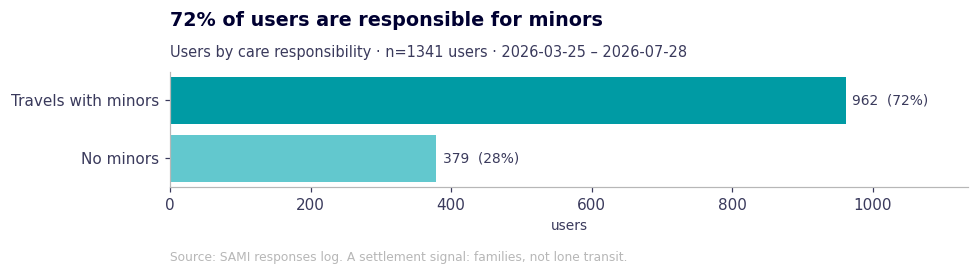

In [8]:
# Figure 6 — care responsibilities (one bar; Minors Si/No)
care = users["Minors"].map({"Si": "Travels with minors", "No": "No minors"}).value_counts()
care = care.reindex(["Travels with minors", "No minors"]).dropna()
share = 100 * care / care.sum()
fig, ax = plt.subplots(figsize=(9, 2.6))
ax.barh(care.index[::-1], care.values[::-1], color=[theme.AGUA_MID, theme.PRIMARY])
for y, (n, p) in enumerate(zip(care.values[::-1], share.values[::-1])):
    ax.annotate(f"{int(n)}  ({p:.0f}%)", (n, y), xytext=(4, 0), textcoords="offset points",
                va="center", fontsize=9, color=theme.INK2)
ax.set_xlim(0, care.max() * 1.18); ax.set_xlabel("users", fontsize=9)
titled(ax, f"{share.iloc[0]:.0f}% of users are responsible for minors",
       f"Users by care responsibility · n={int(care.sum())} users · {WINDOW}",
       source="Source: SAMI responses log. A settlement signal: families, not lone transit.")
plt.tight_layout(); plt.show()

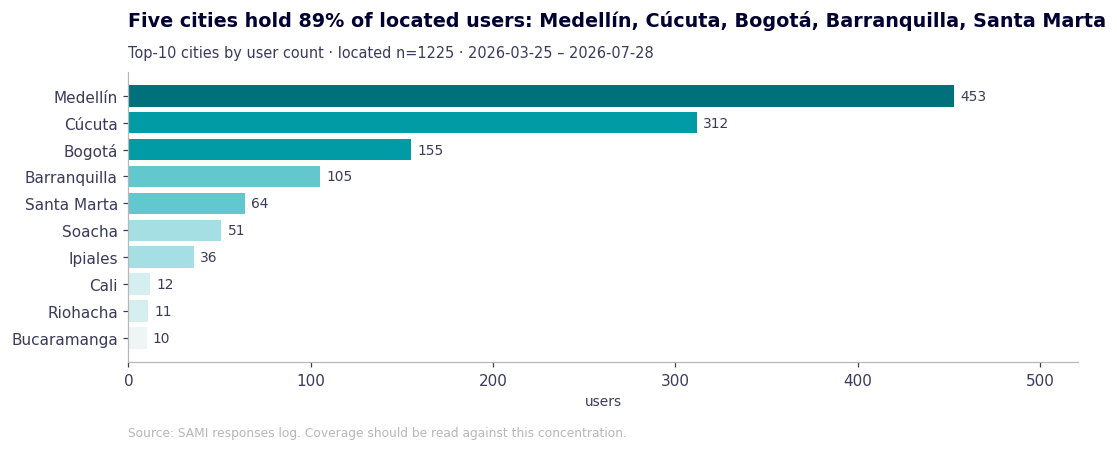

In [9]:
# Figure 7 — city top-10 bar
city = users.loc[users["city_canon"] != "Otra", "city_canon"].value_counts().head(10)
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.barh(city.index[::-1], city.values[::-1], color=theme.seq_colors(len(city)))
for y, n in enumerate(city.values[::-1]):
    ax.annotate(f"{n}", (n, y), xytext=(4, 0), textcoords="offset points",
                va="center", fontsize=9, color=theme.INK2)
top5 = 100 * city.head(5).sum() / (users["city_canon"] != "Otra").sum()
ax.set_xlim(0, city.max() * 1.15); ax.set_xlabel("users", fontsize=9)
titled(ax, f"Five cities hold {top5:.0f}% of located users: {', '.join(city.head(5).index)}",
       f"Top-10 cities by user count · located n={(users['city_canon']!='Otra').sum()} · {WINDOW}",
       source="Source: SAMI responses log. Coverage should be read against this concentration.")
plt.tight_layout(); plt.show()

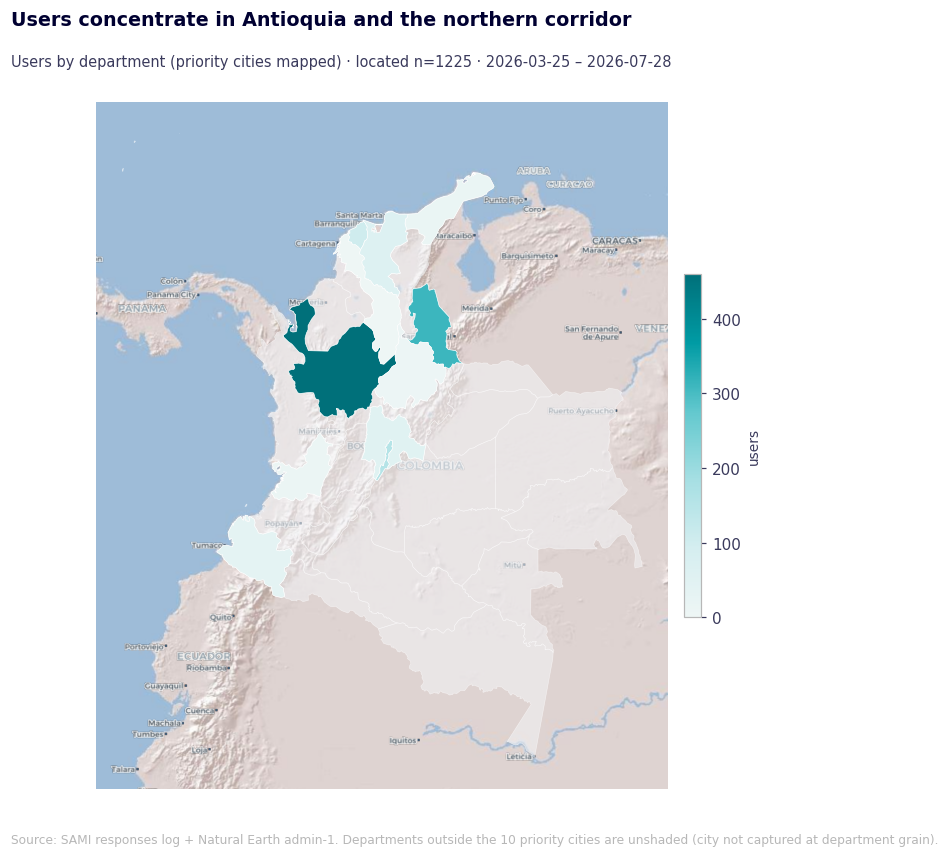

In [10]:
# Figure 8 — department choropleth (users per department)
dept_counts = users["department"].value_counts()
fig, ax = plt.subplots(figsize=(7.5, 8))
sm = geo.dept_choropleth(ax, dept_counts)
cb = fig.colorbar(sm, ax=ax, shrink=0.5, pad=0.02); cb.set_label("users", fontsize=9)
top_dept = dept_counts.index[0]
titled_map(fig, ax, f"Users concentrate in {top_dept} and the northern corridor",
           f"Users by department (priority cities mapped) · located n={int(dept_counts.sum())} · {WINDOW}",
           "Source: SAMI responses log + Natural Earth admin-1. Departments outside the 10 priority "
           "cities are unshaded (city not captured at department grain).")
plt.show()

## 3 · Migration journey

How long have they been away, and where are they heading? Together these reframe SAMI's
mandate from *transit* to *settlement*.

**This series is frozen.** The question *"¿Hace cuánto saliste de tu país de
nacionalidad?"* (Q9) was removed when the survey was rewritten, so this chart
covers the v1 cohort only and will not grow. It is shown because it is the only
evidence on time-since-departure that exists, not because it is current.


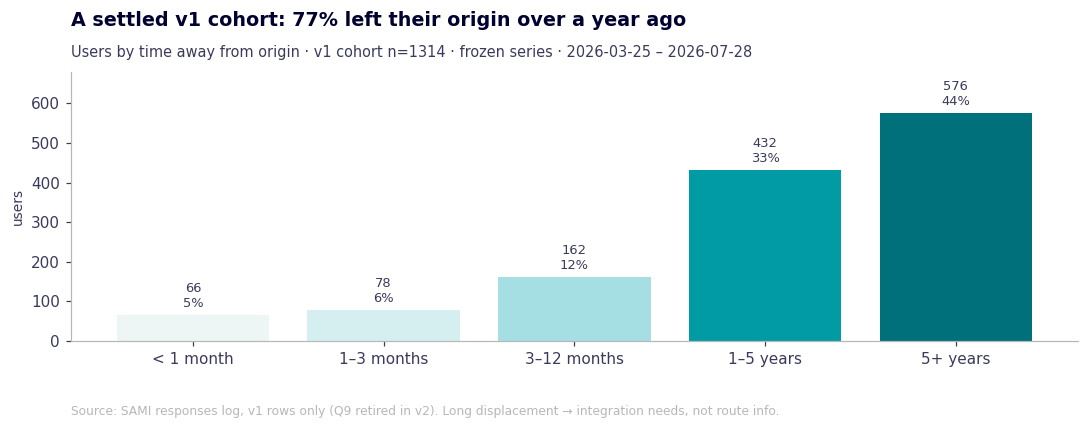

In [11]:
# Figure 9 — time-away distribution (ordered) — v1 cohort only, frozen series
# (cohort.POLICY: away_duration_canon is V1_ONLY; Q9 was removed for v2)
aw = users.loc[users["instrument_version"] == "v1", "away_duration_canon"].dropna()
order = [x for x in canon.AWAY_DURATION_ORDER if x in aw.unique()]
counts = aw.value_counts().reindex(order)
labels = [canon.AWAY_DURATION_DISPLAY_EN[x] for x in order]
share = 100 * counts / counts.sum()
fig, ax = plt.subplots(figsize=(10, 4.0))
ax.bar(labels, counts.values, color=theme.seq_colors(len(counts)))
for x, (n, p) in enumerate(zip(counts.values, share.values)):
    ax.annotate(f"{n}\n{p:.0f}%", (x, n), xytext=(0, 3), textcoords="offset points",
                ha="center", va="bottom", fontsize=8.5, color=theme.INK2)
ax.set_ylim(0, counts.max() * 1.18); ax.set_ylabel("users", fontsize=9)
long = 100 * counts.reindex([x for x in order if x in
        ("Entre 1 a 5 años", "Hace más de 5 años")]).sum() / counts.sum()
titled(ax, f"A settled v1 cohort: {long:.0f}% left their origin over a year ago",
       f"Users by time away from origin · v1 cohort n={int(counts.sum())} · frozen series · {WINDOW}",
       source="Source: SAMI responses log, v1 rows only (Q9 retired in v2). Long displacement → integration needs, not route info.")
plt.tight_layout(); plt.show()


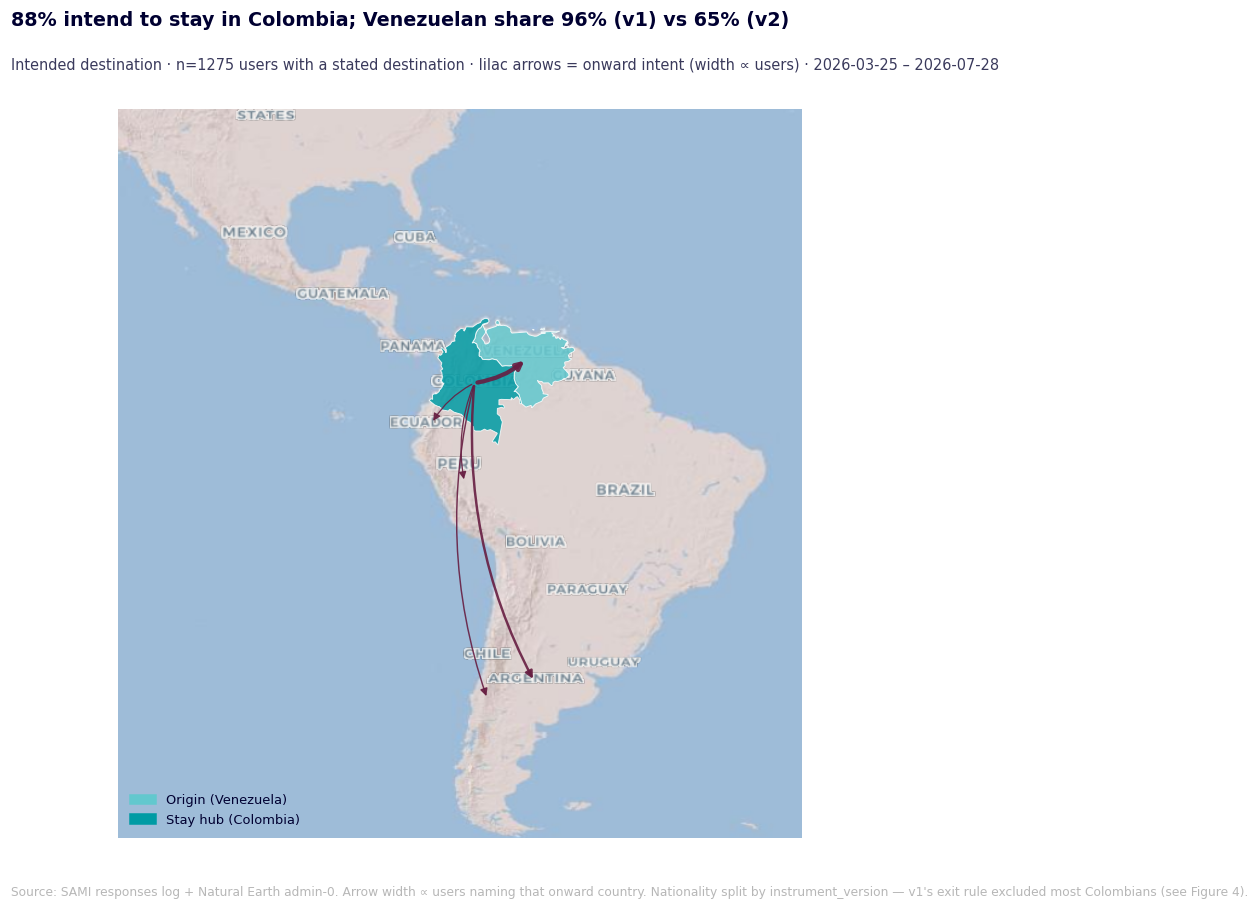

In [12]:
# Figure 10 — Americas migration flow map (origin fill / stay hub / onward arrows)
onward = users["Destination_Country"].value_counts().to_dict()   # non-null destinations
n_dest = int(sum(onward.values()))
stay = 100 * onward.get("Colombia", 0) / n_dest                  # % of stated destinations = Colombia (poolable)
# nationality_canon is SPLIT in cohort.POLICY — v1's exit rule pushes its Venezuelan
# share up (Colombians screened out), v2 removed that exit. Pooling here would
# contradict the split figure given in Figure 4 and the §4 summary, so report
# both cohort shares instead of one pooled number.
ve_v1 = 100 * (users.loc[users["instrument_version"] == "v1", "nationality_canon"] == "Venezuela").mean()
ve_v2 = 100 * (users.loc[users["instrument_version"] == "v2", "nationality_canon"] == "Venezuela").mean()
fig, ax = plt.subplots(figsize=(8.5, 8.5))
geo.americas_flow_map(ax, origin="Venezuela", hub="Colombia", onward=onward)
handles = [Patch(color=theme.AGUA_MID, label="Origin (Venezuela)"),
           Patch(color=theme.PRIMARY, label="Stay hub (Colombia)")]
ax.legend(handles=handles, loc="lower left", frameon=False, fontsize=8.5)
titled_map(fig, ax, f"{stay:.0f}% intend to stay in Colombia; Venezuelan share {ve_v1:.0f}% (v1) vs {ve_v2:.0f}% (v2)",
           f"Intended destination · n={n_dest} users with a stated destination · lilac arrows = onward intent (width ∝ users) · {WINDOW}",
           "Source: SAMI responses log + Natural Earth admin-0. Arrow width ∝ users naming that onward country. "
           "Nationality split by instrument_version — v1's exit rule excluded most Colombians (see Figure 4).")
plt.show()


## 4 · What we now know

In [13]:
lines = [
    f"1. Reach vs. representativeness: SAMI logged {N_USERS} users over {WINDOW}; "
    f"MEAL covers only {100*len(m)/N_USERS:.1f}% — every survey claim stays indicative.",
    f"2. Majority women ({100*(users['gender_clean']=='Mujer').mean():.0f}%), working-age "
    f"(median {users.loc[users['age_num']>=18,'age_num'].median():.0f}); "
    f"{100*(users['Minors']=='Si').mean():.0f}% responsible for minors → families, not lone transit.",
    f"3. Predominantly Venezuelan in both cohorts (v1 "
    f"{100*(users.loc[users['instrument_version']=='v1','nationality_canon']=='Venezuela').mean():.0f}%, v2 "
    f"{100*(users.loc[users['instrument_version']=='v2','nationality_canon']=='Venezuela').mean():.0f}%) and settled: "
    f"among the v1 cohort — the only one the now-frozen away_duration question covers — "
    f"{100*users.loc[users['instrument_version']=='v1','away_duration_canon'].isin(['Entre 1 a 5 años','Hace más de 5 años']).mean():.0f}% "
    f"left their origin over a year ago.",
    f"4. Geographically concentrated: five cities hold most located users; "
    f"{100*users['Destination_Country'].eq('Colombia').sum()/users['Destination_Country'].notna().sum():.0f}% "
    f"of users with a stated destination intend to stay in Colombia.",
    "5. Implication for programme design: this is an INTEGRATION audience "
    "(documentation, health, employment), not a route-information one.",
]
print("\n".join(lines))


1. Reach vs. representativeness: SAMI logged 1392 users over 2026-03-25 – 2026-07-28; MEAL covers only 8.3% — every survey claim stays indicative.
2. Majority women (74%), working-age (median 33); 69% responsible for minors → families, not lone transit.
3. Predominantly Venezuelan in both cohorts (v1 96%, v2 65%) and settled: among the v1 cohort — the only one the now-frozen away_duration question covers — 77% left their origin over a year ago.
4. Geographically concentrated: five cities hold most located users; 88% of users with a stated destination intend to stay in Colombia.
5. Implication for programme design: this is an INTEGRATION audience (documentation, health, employment), not a route-information one.


## 5 · Registration funnel

How many people who started the registration survey actually finished it? v1's
rows are migrated intakes — the legacy platform never tracked partial
registration attempts, so every v1 row completes by construction, not by
outcome. v2 exports every stage, so its cohort is the only place real
drop-off shows up. The two must be read as separate panels, never pooled:
pooling would bury v2's genuine attrition under v1's artificial 100%.


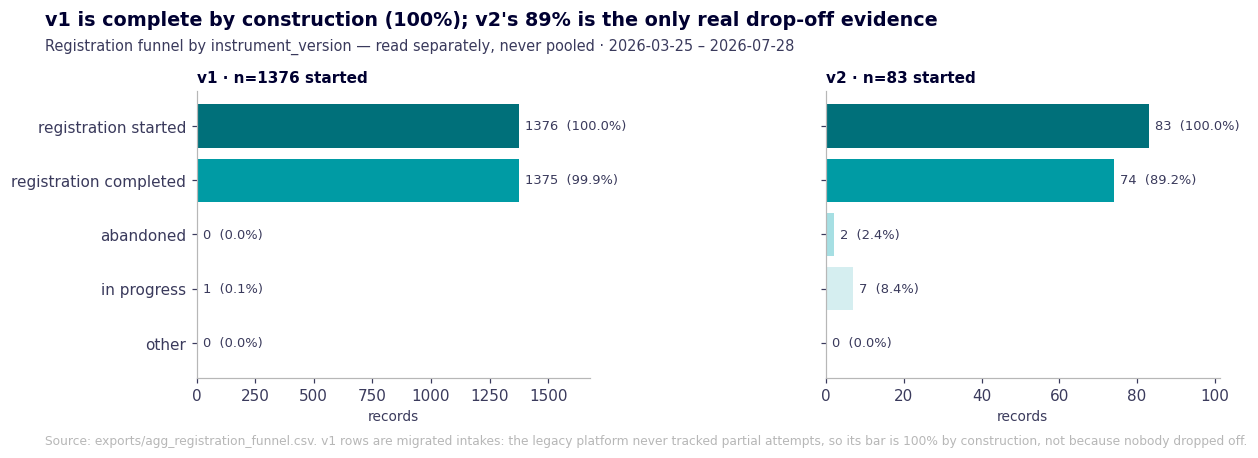

The only real drop-off evidence: of 83 v2 registrations, 2 were abandoned and 7 are still in progress. Caveat: 83 records over five days — treat the shape as indicative and redraw it once the sample grows.


In [14]:
# Figure 11 — registration funnel, split by instrument_version (never pool:
# v1 rows are migrated intakes with no drop-off tracking, so v1 completes
# 100% by construction; only v2 carries real funnel evidence)
funnel = pd.read_csv(_src.parent / "exports" / "agg_registration_funnel.csv")
STAGE_ORDER = funnel.sort_values("stage_order")["stage"].unique().tolist()

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for ax, ver in [(a1, "v1"), (a2, "v2")]:
    sub = (funnel[funnel["instrument_version"] == ver]
           .set_index("stage")[["n", "pct_of_started"]].reindex(STAGE_ORDER))
    ax.barh(STAGE_ORDER[::-1], sub["n"].values[::-1], color=theme.seq_colors(len(STAGE_ORDER)))
    for y, (n, p) in enumerate(zip(sub["n"].values[::-1], sub["pct_of_started"].values[::-1])):
        ax.annotate(f"{int(n)}  ({p:.1f}%)", (n, y), xytext=(4, 0), textcoords="offset points",
                    va="center", fontsize=8.5, color=theme.INK2)
    n_started = int(sub["n"].iloc[0])
    ax.set_xlim(0, sub["n"].max() * 1.22); ax.set_xlabel("records", fontsize=9)
    ax.set_title(f"{ver} · n={n_started} started", loc="left", fontsize=10,
                 fontweight="semibold", color=theme.INK, pad=6)
fig.subplots_adjust(top=0.78, bottom=0.16, wspace=0.6)
v1_pct = funnel.loc[(funnel["instrument_version"] == "v1") & (funnel["stage"] == "registration completed"),
                     "pct_of_started"].iloc[0]
v2_pct = funnel.loc[(funnel["instrument_version"] == "v2") & (funnel["stage"] == "registration completed"),
                     "pct_of_started"].iloc[0]
fig.text(0.01, 0.955, f"v1 is complete by construction ({v1_pct:.0f}%); v2's {v2_pct:.0f}% is the only real drop-off evidence",
         fontsize=12.5, fontweight="semibold", color=theme.INK, ha="left", va="top")
fig.text(0.01, 0.895, f"Registration funnel by instrument_version — read separately, never pooled · {WINDOW}",
         fontsize=9.5, color=theme.INK2, ha="left", va="top")
fig.text(0.01, 0.01,
         "Source: exports/agg_registration_funnel.csv. v1 rows are migrated intakes: the legacy platform never "
         "tracked partial attempts, so its bar is 100% by construction, not because nobody dropped off.",
         fontsize=8, color=theme.MUTED, ha="left", va="bottom")
plt.show()

v2_started = int(funnel.loc[(funnel["instrument_version"] == "v2") & (funnel["stage"] == "registration started"), "n"].iloc[0])
v2_abandoned = int(funnel.loc[(funnel["instrument_version"] == "v2") & (funnel["stage"] == "abandoned"), "n"].iloc[0])
v2_in_progress = int(funnel.loc[(funnel["instrument_version"] == "v2") & (funnel["stage"] == "in progress"), "n"].iloc[0])
print(f"The only real drop-off evidence: of {v2_started} v2 registrations, {v2_abandoned} were abandoned and "
      f"{v2_in_progress} are still in progress. Caveat: {v2_started} records over five days — treat the shape as "
      f"indicative and redraw it once the sample grows.")


## 6 · Interface language

Which language do users interact in? v2 added an explicit language selector; v1 had
none, so v1's language is an inferred label on a migrated session, not a user choice.
Read the two cohorts separately for that reason — a pooled "3 English users" figure
would quietly merge one inferred v1 label with two real v2 selections.


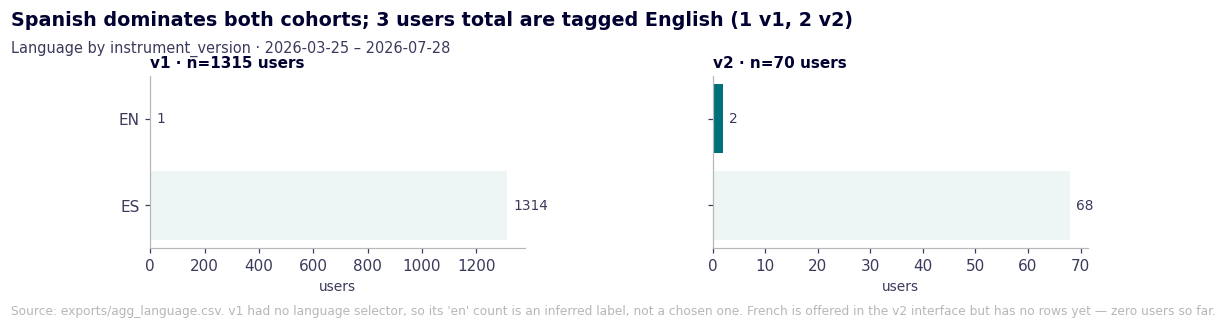

English users: 3 total — 1 under v1 (inferred, no selector existed) and 2 under v2 (explicitly selected).


In [15]:
# Figure 12 — interface language, split by instrument_version (v1 has no
# selector, so its language is inferred, not chosen; keep the two separate)
lang = pd.read_csv(_src.parent / "exports" / "agg_language.csv")
LANGS = sorted(lang["language"].unique())
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.0), sharey=True)
for ax, ver in [(a1, "v1"), (a2, "v2")]:
    sub = lang[lang["instrument_version"] == ver].set_index("language")["n_users"].reindex(LANGS).fillna(0)
    ax.barh([l.upper() for l in LANGS][::-1], sub.values[::-1], color=theme.seq_colors(len(LANGS)))
    for y, n in enumerate(sub.values[::-1]):
        ax.annotate(f"{int(n)}", (n, y), xytext=(4, 0), textcoords="offset points",
                    va="center", fontsize=9, color=theme.INK2)
    n_cohort = int(sub.sum())
    ax.set_xlabel("users", fontsize=9)
    ax.set_title(f"{ver} · n={n_cohort} users", loc="left", fontsize=10,
                 fontweight="semibold", color=theme.INK, pad=6)
fig.subplots_adjust(top=0.74, bottom=0.22, wspace=0.5)
n_en_total = int(lang.loc[lang["language"] == "en", "n_users"].sum())
n_en_v1 = int(lang.loc[(lang["language"] == "en") & (lang["instrument_version"] == "v1"), "n_users"].sum())
n_en_v2 = int(lang.loc[(lang["language"] == "en") & (lang["instrument_version"] == "v2"), "n_users"].sum())
fig.text(0.01, 0.94, f"Spanish dominates both cohorts; {n_en_total} users total are tagged English ({n_en_v1} v1, {n_en_v2} v2)",
         fontsize=12.5, fontweight="semibold", color=theme.INK, ha="left", va="top")
fig.text(0.01, 0.85, f"Language by instrument_version · {WINDOW}",
         fontsize=9.5, color=theme.INK2, ha="left", va="top")
fig.text(0.01, 0.01,
         "Source: exports/agg_language.csv. v1 had no language selector, so its 'en' count is an inferred label, "
         "not a chosen one. French is offered in the v2 interface but has no rows yet — zero users so far.",
         fontsize=8, color=theme.MUTED, ha="left", va="bottom")
plt.show()
print(f"English users: {n_en_total} total — {n_en_v1} under v1 (inferred, no selector existed) "
      f"and {n_en_v2} under v2 (explicitly selected).")


### Reconciliation table (P10) — bottom · must match the top

In [16]:
recon_bottom = qa.reconciliation_table(d.responses, d.messages, d.meal)
assert recon_bottom.equals(d.reconciliation), "Reconciliation drift between top and bottom!"
print("Reconciliation stable top-to-bottom ✓")
display(recon_bottom)

Reconciliation stable top-to-bottom ✓


,metric,value
0,users,1392
1,records,1459
2,messages,4663
3,users_with_text,1198
4,meal_responses,115
5,meal_response_rate_pct,8.3
6,repeat_askers_pct,10.6
7,negative_tone_pct,pending
